# Modelos base sobre la generación real de plantas solares en Colombia

Este cuaderno corre los modelos base del curso sobre la base construida en `Clima_a_Generacion_Colombia.ipynb` (`tabla_diaria_colombia.csv`):
16 plantas, 6 zonas y 8,589 días planta, de enero de 2024 a febrero de 2026. Dos tareas:

- Regresión: predecir el factor de capacidad (FC) del día con el clima del día.
- Clasificación: predecir si el día fue bajo, medio o alto para esa planta.

Variables: radiación, nubosidad, temperatura, humedad y viento del día (Open-Meteo, `best_match`).

## Esquema del benchmark

La partición va primero. El nivel de cada planta y los cortes de las clases salen solo de su pasado.

![Esquema del benchmark de Colombia](fig_pipeline_benchmark_colombia.png)

## 1. Diseño y cómo se evita la fuga de información

Partición primero. Cada planta se parte en el tiempo: la primera mitad de sus días es el pasado y la segunda mitad es la prueba. Además se deja fuera una zona
completa, porque plantas a menos de 100 km comparten el clima del mismo día (Roberts et al., 2017). Se repite con cada una de las 6 zonas.

Todo lo que se calcula a partir de los datos sale solo del pasado o del entrenamiento:
- El nivel de cada planta (FC medio y media de cada variable de clima) se calcula con la primera mitad de sus días. Para las plantas de la zona de prueba esas
  filas sirven solo para el nivel y no entran al entrenamiento del modelo.
- Los cortes de bajo, medio y alto son los terciles del FC centrado de la primera mitad de cada planta.
- El escalado y la calibración de probabilidades van dentro de un `Pipeline` y se ajustan con las filas de entrenamiento de cada partición (Kaufman et al., 2012).

Ajuste de hiperparámetros: validación anidada (Varma y Simon, 2006; Cawley y Talbot, 2010). El bucle interno usa solo las filas de entrenamiento y deja fuera,
una a la vez, cada zona de entrenamiento (leave-one-group-out). Elige con R² (regresión) o F1 macro (clasificación). El bucle externo solo mide. Así el resultado reportado no está
inflado por haber elegido los hiperparámetros mirando la prueba.

Contraste: los modelos por defecto se repiten con una partición aleatoria de filas para ver cuánto infla el resultado.

Métricas de regresión: R² dentro de la planta (mediana entre plantas), RMSE, MAE y MAE relativo al FC medio de la planta.
Métricas de clasificación: F1 macro, exactitud, exactitud balanceada, precisión y recall macro, AUC ROC macro uno contra el resto (Fawcett, 2006) y kappa
ponderado cuadrático (Cohen, 1968), porque las clases tienen orden: confundir un día bajo con uno alto es peor que confundirlo con uno medio.

In [1]:
import time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.svm import SVR, SVC, LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.model_selection import KFold, GridSearchCV, LeaveOneGroupOut
from sklearn.metrics import (r2_score, mean_squared_error, f1_score, accuracy_score, balanced_accuracy_score, precision_score,
                             recall_score, roc_auc_score, roc_curve, cohen_kappa_score, confusion_matrix, ConfusionMatrixDisplay)

warnings.filterwarnings("ignore")
SEED = 42

tabla = pd.read_csv("tabla_diaria_colombia.csv", parse_dates=["date"]).sort_values(["code", "date"]).reset_index(drop=True)
VARS = ["rad_bm", "nube_bm", "temp_bm", "humedad_bm", "viento_bm"]
tabla["prueba_t"] = tabla.groupby("code").cumcount() >= tabla.groupby("code").fc.transform("size") // 2
print(tabla.shape, "| plantas:", tabla.code.nunique(), "| zonas:", tabla.grupo.nunique())

(8589, 24) | plantas: 16 | zonas: 6


In [2]:
def prepara(datos, filas_nivel):
    # Centra con el nivel de cada planta calculado SOLO con filas_nivel (su pasado) y define las clases con sus terciles
    medias = datos[filas_nivel].groupby("code")[VARS + ["fc"]].mean()
    d = datos.copy()
    for v in VARS + ["fc"]:
        d[v + "_c"] = d[v] - d.code.map(medias[v])
    cortes = d[filas_nivel].groupby("code").fc_c.quantile([1 / 3, 2 / 3]).unstack()
    lo, hi = d.code.map(cortes[1 / 3]), d.code.map(cortes[2 / 3])
    d["clase"] = np.where(d.fc_c <= lo, 0, np.where(d.fc_c <= hi, 1, 2))   # 0 bajo, 1 medio, 2 alto
    return d

def particiones_zona():
    for z in sorted(tabla.grupo.unique()):
        ent = (~tabla.prueba_t) & (tabla.grupo != z)   # el modelo aprende solo del pasado de otras zonas
        pru = tabla.prueba_t & (tabla.grupo == z)       # y se evalúa en el futuro de la zona que dejó fuera
        yield ent.values, pru.values, (~tabla.prueba_t).values

def particiones_aleatorias():
    for tr, te in KFold(5, shuffle=True, random_state=SEED).split(tabla):
        ent = np.zeros(len(tabla), bool); ent[tr] = True
        yield ent, ~ent, ent

pipe = lambda m: Pipeline([("esc", StandardScaler()), ("m", m)])
REG = {
    "Referencia: nivel de la planta": DummyRegressor(strategy="constant", constant=0.0),
    "Regresión lineal": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001, max_iter=10000),
    "KNN": KNeighborsRegressor(n_neighbors=25),
    "SVR RBF": SVR(C=1.0, epsilon=0.01),
}
CLF = {
    "Referencia: clase más frecuente": DummyClassifier(strategy="most_frequent"),
    "Regresión logística": LogisticRegression(max_iter=1000),
    "Naive Bayes gaussiano": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=25),
    "SVM lineal (calibrado)": CalibratedClassifierCV(LinearSVC(dual=False), cv=3),
    "SVM RBF": SVC(kernel="rbf", probability=True, random_state=SEED),
}
GRID_REG = {
    "Ridge": {"m__alpha": [0.001, 0.01, 0.1, 1, 10, 100, 1000]},
    "Lasso": {"m__alpha": [1e-5, 1e-4, 1e-3, 1e-2]},
    "KNN": {"m__n_neighbors": [5, 15, 25, 51, 101], "m__weights": ["uniform", "distance"]},
    "SVR RBF": {"m__C": [0.1, 1, 10], "m__epsilon": [0.005, 0.02], "m__gamma": ["scale", 0.1]},
}
GRID_CLF = {
    "Regresión logística": {"m__C": [0.01, 0.1, 1, 10, 100]},
    "Naive Bayes gaussiano": {"m__var_smoothing": [1e-9, 1e-7, 1e-5, 1e-3]},
    "KNN": {"m__n_neighbors": [5, 15, 25, 51, 101], "m__weights": ["uniform", "distance"]},
    "SVM lineal (calibrado)": {"m__estimator__C": [0.01, 0.1, 1, 10]},
    "SVM RBF": {"m__C": [0.1, 1, 10], "m__gamma": ["scale", 0.1]},
}

In [3]:
def mide(tarea, p):
    if tarea == "reg":
        r2 = p.groupby("code").apply(lambda g: r2_score(g.fc_c, g.pred))
        mae_rel = p.groupby("code").apply(lambda g: np.abs(g.fc_c - g.pred).mean() / g.fc.mean())
        return {"r2_mediana": r2.median(), "r2_min": r2.min(), "r2_max": r2.max(),
                "rmse": np.sqrt(mean_squared_error(p.fc_c, p.pred)), "mae": np.abs(p.fc_c - p.pred).mean(), "mae_rel_medio": mae_rel.mean()}
    proba = np.vstack(p.proba.values)
    return {"f1_macro": f1_score(p.clase, p.pred, average="macro"), "exactitud": accuracy_score(p.clase, p.pred),
            "exactitud_bal": balanced_accuracy_score(p.clase, p.pred), "precision_macro": precision_score(p.clase, p.pred, average="macro", zero_division=0),
            "recall_macro": recall_score(p.clase, p.pred, average="macro"),
            "auc_ovr": roc_auc_score(p.clase, proba, multi_class="ovr", average="macro", labels=[0, 1, 2]),
            "kappa_cuad": cohen_kappa_score(p.clase, p.pred, weights="quadratic")}

def evalua(tarea, nombre, feats, particionador, grid=None):
    modelo = (REG if tarea == "reg" else CLF)[nombre]
    cols = [v + "_c" for v in feats]
    piezas, elegidos = [], []
    for ent, pru, nivel in particionador():
        d = prepara(tabla, nivel)
        y = d.fc_c if tarea == "reg" else d.clase
        est = pipe(clone(modelo))
        if grid:   # validación anidada: el bucle interno deja fuera una zona de entrenamiento a la vez
            est = GridSearchCV(est, grid, cv=LeaveOneGroupOut(), scoring="r2" if tarea == "reg" else "f1_macro", n_jobs=-1, refit=True)
            est.fit(d.loc[ent, cols], y[ent], groups=d.loc[ent, "grupo"])
            elegidos.append({p.replace("m__", ""): v for p, v in est.best_params_.items()})
        else:
            est.fit(d.loc[ent, cols], y[ent])
        out = d.loc[pru, ["code", "fc_c", "clase", "fc"]].assign(pred=est.predict(d.loc[pru, cols]))
        if tarea == "clf":
            out["proba"] = list(est.predict_proba(d.loc[pru, cols]))
        piezas.append(out)
    p = pd.concat(piezas)
    return mide(tarea, p), elegidos, p

def tabla_modelos(tarea, feats, particionador, ajustar=False):
    filas, params, preds = [], {}, {}
    grids = GRID_REG if tarea == "reg" else GRID_CLF
    for nombre in (REG if tarea == "reg" else CLF):
        t0 = time.time()
        m, el, p = evalua(tarea, nombre, feats, particionador, grids.get(nombre) if ajustar else None)
        filas.append({"modelo": nombre, **m, "segundos": time.time() - t0})
        params[nombre], preds[nombre] = el, p
    return pd.DataFrame(filas).set_index("modelo"), params, preds

## 2. Regresión

In [4]:
reg_def, _, _ = tabla_modelos("reg", VARS, particiones_zona)
reg_aj, par_reg, _ = tabla_modelos("reg", VARS, particiones_zona, ajustar=True)
display(reg_aj.round(4))
pd.DataFrame({"R² por defecto": reg_def.r2_mediana, "R² ajustado": reg_aj.r2_mediana,
              "MAE rel. por defecto": reg_def.mae_rel_medio, "MAE rel. ajustado": reg_aj.mae_rel_medio}).round(3)

,r2_mediana,r2_min,r2_max,rmse,mae,mae_rel_medio,segundos
modelo,,,,,,,
Referencia: nivel de la planta,-0.0392,-0.9499,-0.0000,0.0627,0.0484,0.1957,0.1443
Regresión lineal,0.4661,-0.4687,0.6186,0.0456,0.0347,0.1405,0.1334
Ridge,0.4611,-0.4733,0.6134,0.0457,0.0347,0.1407,10.9374
Lasso,0.4685,-0.4623,0.6178,0.0455,0.0346,0.1402,0.4952
KNN,0.4139,-0.4372,0.5213,0.0470,0.0361,0.1470,1.8872
SVR RBF,0.4066,-0.2924,0.5283,0.0465,0.0353,0.1442,41.3543


,R² por defecto,R² ajustado,MAE rel. por defecto,MAE rel. ajustado
modelo,,,,
Referencia: nivel de la planta,-0.039,-0.039,0.196,0.196
Regresión lineal,0.466,0.466,0.140,0.140
Ridge,0.466,0.461,0.140,0.141
Lasso,0.469,0.469,0.140,0.140
KNN,0.396,0.414,0.150,0.147
SVR RBF,0.358,0.407,0.152,0.144


In [5]:
for nombre, el in par_reg.items():
    if el:
        print(f"{nombre}: " + " | ".join(str(e) for e in el))

Ridge: {'alpha': 100} | {'alpha': 100} | {'alpha': 100} | {'alpha': 100} | {'alpha': 100} | {'alpha': 100}
Lasso: {'alpha': 0.001} | {'alpha': 0.0001} | {'alpha': 0.001} | {'alpha': 0.001} | {'alpha': 0.001} | {'alpha': 0.001}
KNN: {'n_neighbors': 101, 'weights': 'uniform'} | {'n_neighbors': 101, 'weights': 'distance'} | {'n_neighbors': 101, 'weights': 'uniform'} | {'n_neighbors': 101, 'weights': 'uniform'} | {'n_neighbors': 101, 'weights': 'uniform'} | {'n_neighbors': 101, 'weights': 'uniform'}
SVR RBF: {'C': 0.1, 'epsilon': 0.02, 'gamma': 0.1} | {'C': 0.1, 'epsilon': 0.02, 'gamma': 0.1} | {'C': 0.1, 'epsilon': 0.02, 'gamma': 0.1} | {'C': 0.1, 'epsilon': 0.02, 'gamma': 0.1} | {'C': 0.1, 'epsilon': 0.02, 'gamma': 0.1} | {'C': 0.1, 'epsilon': 0.02, 'gamma': 0.1}


## 3. Clasificación: día bajo, medio o alto

Las clases están balanceadas por construcción (terciles). La referencia de la clase más frecuente da un F1 macro cercano a 0.18, una exactitud balanceada de 0.33 y un AUC de 0.5.

In [6]:
clf_def, _, _ = tabla_modelos("clf", VARS, particiones_zona)
clf_aj, par_clf, pred_clf = tabla_modelos("clf", VARS, particiones_zona, ajustar=True)
display(clf_aj.round(3))
pd.DataFrame({"F1 por defecto": clf_def.f1_macro, "F1 ajustado": clf_aj.f1_macro,
              "AUC por defecto": clf_def.auc_ovr, "AUC ajustado": clf_aj.auc_ovr}).round(3)

,f1_macro,exactitud,exactitud_bal,precision_macro,recall_macro,auc_ovr,kappa_cuad,segundos
modelo,,,,,,,,
Referencia: clase más frecuente,0.178,0.364,0.333,0.121,0.333,0.500,0.000,0.129
Regresión logística,0.572,0.576,0.574,0.570,0.574,0.765,0.575,0.704
Naive Bayes gaussiano,0.535,0.544,0.540,0.538,0.540,0.737,0.508,0.545
KNN,0.564,0.571,0.566,0.567,0.566,0.753,0.561,1.755
SVM lineal (calibrado),0.542,0.558,0.559,0.539,0.559,0.751,0.553,1.220
SVM RBF,0.572,0.576,0.570,0.580,0.570,0.759,0.568,41.211


,F1 por defecto,F1 ajustado,AUC por defecto,AUC ajustado
modelo,,,,
Referencia: clase más frecuente,0.178,0.178,0.500,0.500
Regresión logística,0.572,0.572,0.766,0.765
Naive Bayes gaussiano,0.535,0.535,0.737,0.737
KNN,0.550,0.564,0.743,0.753
SVM lineal (calibrado),0.542,0.542,0.752,0.751
SVM RBF,0.570,0.572,0.758,0.759


In [7]:
for nombre, el in par_clf.items():
    if el:
        print(f"{nombre}: " + " | ".join(str(e) for e in el))

Regresión logística: {'C': 1} | {'C': 10} | {'C': 0.1} | {'C': 10} | {'C': 0.1} | {'C': 0.1}
Naive Bayes gaussiano: {'var_smoothing': 1e-09} | {'var_smoothing': 1e-09} | {'var_smoothing': 1e-09} | {'var_smoothing': 1e-09} | {'var_smoothing': 1e-09} | {'var_smoothing': 1e-09}
KNN: {'n_neighbors': 101, 'weights': 'uniform'} | {'n_neighbors': 101, 'weights': 'uniform'} | {'n_neighbors': 101, 'weights': 'uniform'} | {'n_neighbors': 101, 'weights': 'uniform'} | {'n_neighbors': 101, 'weights': 'uniform'} | {'n_neighbors': 101, 'weights': 'uniform'}
SVM lineal (calibrado): {'estimator__C': 0.01} | {'estimator__C': 1} | {'estimator__C': 0.01} | {'estimator__C': 0.01} | {'estimator__C': 0.01} | {'estimator__C': 0.1}
SVM RBF: {'C': 1, 'gamma': 0.1} | {'C': 1, 'gamma': 0.1} | {'C': 1, 'gamma': 0.1} | {'C': 1, 'gamma': 0.1} | {'C': 1, 'gamma': 0.1} | {'C': 1, 'gamma': 0.1}


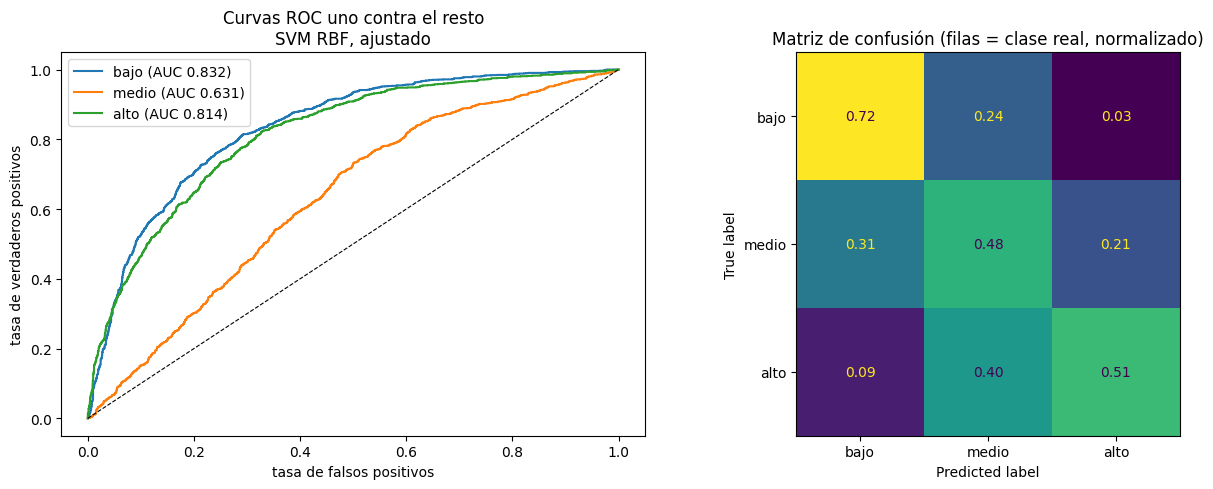

In [8]:
mejor = clf_aj.f1_macro.drop("Referencia: clase más frecuente").idxmax()
p = pred_clf[mejor]; proba = np.vstack(p.proba.values); Y = label_binarize(p.clase, classes=[0, 1, 2])
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for c, nombre in enumerate(["bajo", "medio", "alto"]):
    fpr, tpr, _ = roc_curve(Y[:, c], proba[:, c])
    axes[0].plot(fpr, tpr, label=f"{nombre} (AUC {roc_auc_score(Y[:, c], proba[:, c]):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=.8); axes[0].set_xlabel("tasa de falsos positivos"); axes[0].set_ylabel("tasa de verdaderos positivos")
axes[0].set_title(f"Curvas ROC uno contra el resto\n{mejor}, ajustado"); axes[0].legend()
ConfusionMatrixDisplay(confusion_matrix(p.clase, p.pred, normalize="true"), display_labels=["bajo", "medio", "alto"]).plot(ax=axes[1], values_format=".2f", colorbar=False)
axes[1].set_title("Matriz de confusión (filas = clase real, normalizado)")
fig.tight_layout(); fig.savefig("fig_benchmark_colombia_roc_confusion.png", dpi=130, bbox_inches="tight"); plt.show()

## 4. Cuánto aportan las variables además de la radiación

Modelos por defecto, mismo diseño, con solo la radiación como variable.

In [9]:
reg_rad, _, _ = tabla_modelos("reg", ["rad_bm"], particiones_zona)
clf_rad, _, _ = tabla_modelos("clf", ["rad_bm"], particiones_zona)
display(pd.DataFrame({"R² solo radiación": reg_rad.r2_mediana, "R² todas": reg_def.r2_mediana}).round(3))
pd.DataFrame({"F1 solo radiación": clf_rad.f1_macro, "F1 todas": clf_def.f1_macro}).round(3)

,R² solo radiación,R² todas
modelo,,
Referencia: nivel de la planta,-0.039,-0.039
Regresión lineal,0.495,0.466
Ridge,0.495,0.466
Lasso,0.492,0.469
KNN,0.443,0.396
SVR RBF,0.488,0.358


,F1 solo radiación,F1 todas
modelo,,
Referencia: clase más frecuente,0.178,0.178
Regresión logística,0.569,0.572
Naive Bayes gaussiano,0.578,0.535
KNN,0.539,0.550
SVM lineal (calibrado),0.543,0.542
SVM RBF,0.563,0.570


## 5. Partición aleatoria frente a zona fuera

Modelos por defecto. Con partición aleatoria, días vecinos de la misma planta y de plantas cercanas caen a los dos lados, y el nivel de cada planta se calcula con días de todo el período.

,R² zona fuera,R² aleatoria
modelo,,
Referencia: nivel de la planta,-0.039,-0.000
Regresión lineal,0.466,0.495
Ridge,0.466,0.495
Lasso,0.469,0.495
KNN,0.396,0.467
SVR RBF,0.358,0.479


,F1 zona fuera,F1 aleatoria
modelo,,
Referencia: clase más frecuente,0.178,0.167
Regresión logística,0.572,0.593
Naive Bayes gaussiano,0.535,0.555
KNN,0.550,0.581
SVM lineal (calibrado),0.542,0.564
SVM RBF,0.570,0.598


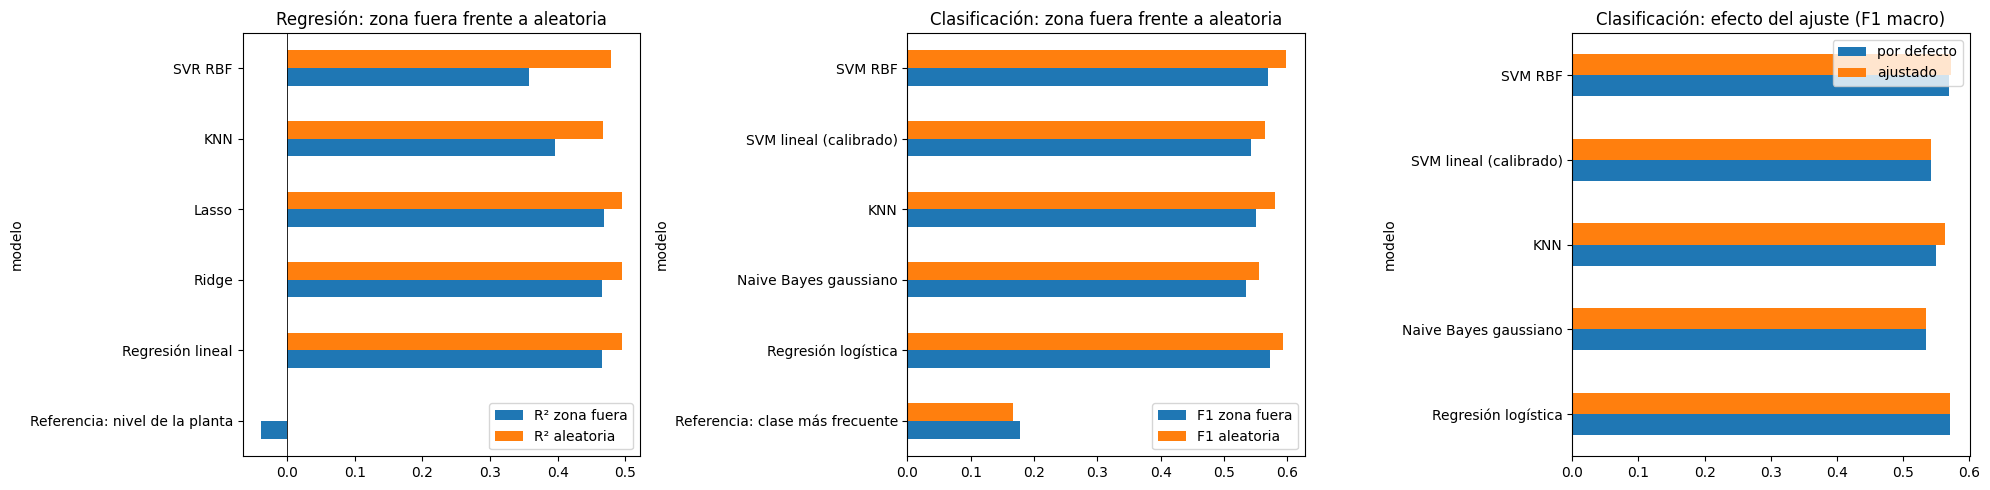

In [10]:
reg_ale, _, _ = tabla_modelos("reg", VARS, particiones_aleatorias)
clf_ale, _, _ = tabla_modelos("clf", VARS, particiones_aleatorias)
comp = pd.DataFrame({"R² zona fuera": reg_def.r2_mediana, "R² aleatoria": reg_ale.r2_mediana})
comp_c = pd.DataFrame({"F1 zona fuera": clf_def.f1_macro, "F1 aleatoria": clf_ale.f1_macro})
display(comp.round(3)); display(comp_c.round(3))
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
comp.plot.barh(ax=axes[0]); axes[0].set_title("Regresión: zona fuera frente a aleatoria"); axes[0].axvline(0, color="k", lw=.6)
comp_c.plot.barh(ax=axes[1]); axes[1].set_title("Clasificación: zona fuera frente a aleatoria")
pd.DataFrame({"por defecto": clf_def.f1_macro, "ajustado": clf_aj.f1_macro}).drop(index="Referencia: clase más frecuente").plot.barh(ax=axes[2])
axes[2].set_title("Clasificación: efecto del ajuste (F1 macro)")
fig.tight_layout(); fig.savefig("fig_benchmark_colombia.png", dpi=130, bbox_inches="tight"); plt.show()

In [11]:
reg_def.to_csv("resultados_colombia_regresion_defecto.csv"); reg_aj.to_csv("resultados_colombia_regresion_ajustado.csv")
clf_def.to_csv("resultados_colombia_clasificacion_defecto.csv"); clf_aj.to_csv("resultados_colombia_clasificacion_ajustado.csv")
print("guardado")

guardado


## 6. Conclusiones

Regresión con hiperparámetros ajustados (validación anidada, zona fuera y futuro de cada planta): Lasso da una mediana de R² de 0.469 dentro de planta,
la regresión lineal 0.466, Ridge 0.461, KNN 0.414 y SVR RBF 0.407. La referencia del nivel de la planta da -0.04. El error absoluto baja de un 20 % del FC medio
con la referencia a un 14 % con los modelos lineales, y el RMSE de 0.063 a 0.046 puntos de FC.

Clasificación del día en bajo, medio o alto, con hiperparámetros ajustados: la regresión logística y el SVM RBF empatan con F1 macro de 0.572. La logística tiene el mayor AUC
(0.765) y el mayor kappa ponderado (0.575). Siguen KNN (0.564), SVM lineal (0.542) y Naive Bayes (0.535). La referencia da 0.178 de F1 y 0.5 de AUC.
Con un AUC de 0.75 a 0.77, si se toma al azar un día de una clase y uno de otra, el modelo ordena bien la pareja tres de cada cuatro veces.

El ajuste de hiperparámetros ayuda poco. Mejora sobre todo a los modelos flexibles: el SVR pasa de 0.358 a 0.407 y KNN de 0.396 a 0.414 en R². Los lineales
no cambian. La búsqueda eligió siempre la opción más suave de la grilla (KNN con 101 vecinos, SVR con C de 0.1 y Ridge con alpha de 100), y KNN y SVR quedaron en el borde de su grilla,
así que una grilla más amplia podría mejorarlos un poco. Con 6 zonas, parece que lo que generaliza es suavizar mucho.

Sobre la base de datos:
- Con pocas zonas, los modelos flexibles sobreajustan. Con solo la radiación, el SVR por defecto sube de 0.36 a 0.49. Las otras variables de clima están muy
  correlacionadas con la radiación y agregan más ruido que información.
- La partición aleatoria infla el resultado: el SVR por defecto pasa de 0.36 a 0.48 en R² y el SVM RBF de 0.570 a 0.598 en F1.
- Hay plantas cuyo nivel cambia con el tiempo. Con el nivel calculado con el pasado, la peor planta queda en R² de -0.46 con los modelos lineales.
- La tecnología de cada planta no está en la base, así que los modelos explican el sube y baja diario y no la diferencia entre plantas.

## Referencias

- Cawley, G. C. y Talbot, N. L. C. (2010). On over-fitting in model selection and subsequent selection bias in performance evaluation. *Journal of Machine Learning Research, 11*, 2079-2107. https://jmlr.org/papers/v11/cawley10a.html
- Cohen, J. (1968). Weighted kappa: nominal scale agreement with provision for scaled disagreement or partial credit. *Psychological Bulletin, 70*, 213-220. https://doi.org/10.1037/h0026256
- Fawcett, T. (2006). An introduction to ROC analysis. *Pattern Recognition Letters, 27*, 861-874. https://doi.org/10.1016/j.patrec.2005.10.010
- Kaufman, S., Rosset, S., Perlich, C. y Stitelman, O. (2012). Leakage in data mining: formulation, detection, and avoidance. *ACM Transactions on Knowledge Discovery from Data, 6*(4), 1-21. https://doi.org/10.1145/2382577.2382579
- Roberts, D. R. et al. (2017). Cross-validation strategies for data with temporal, spatial, hierarchical, or phylogenetic structure. *Ecography, 40*(8), 913-929. https://doi.org/10.1111/ecog.02881
- Varma, S. y Simon, R. (2006). Bias in error estimation when using cross-validation for model selection. *BMC Bioinformatics, 7*, 91. https://doi.org/10.1186/1471-2105-7-91